In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from collections import Counter
from etc import Hamiltonian
import random

In [2]:
# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gml_path = project_root / "data" / "resources" / "generated" / "modified_graph.gml"

In [3]:
G = nx.read_gml(gml_path)

In [4]:
average_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print("Average degree:", average_degree)

Average degree: 4.477777777777778


In [5]:
G.number_of_nodes(), G.number_of_edges()

(3240, 7254)

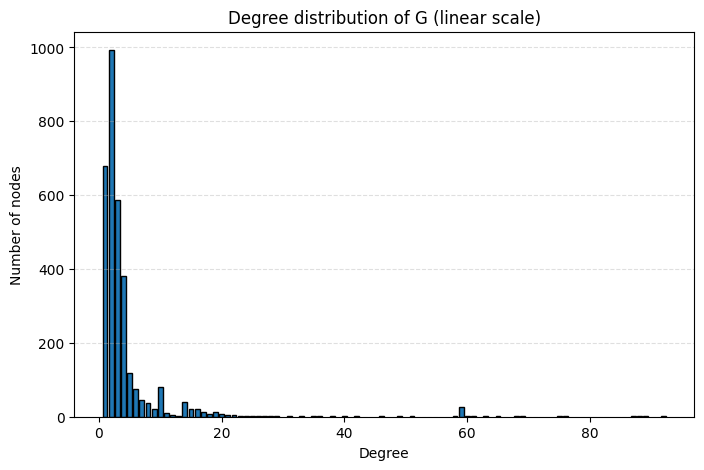

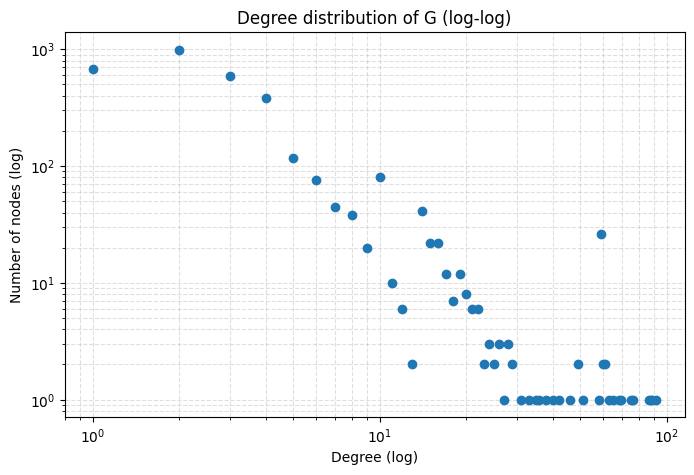

In [67]:
degrees = [d for n, d in G.degree()]
deg_counts = Counter(degrees)
deg, counts = zip(*sorted(deg_counts.items()))

# Linear-scale bar plot
plt.figure(figsize=(8,5))
plt.bar(deg, counts, width=0.8, color='C0', edgecolor='k')
plt.xlabel('Degree')
plt.ylabel('Number of nodes')
plt.title('Degree distribution of G (linear scale)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Log-log plot for heavy-tailed distributions
plt.figure(figsize=(8,5))
plt.loglog(deg, counts, marker='o', linestyle='none')
plt.xlabel('Degree (log)')
plt.ylabel('Number of nodes (log)')
plt.title('Degree distribution of G (log-log)')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.show()

In [68]:
D = np.load(f"{project_root}/data/resources/generated/dist_matrix.npy")

In [69]:
H = Hamiltonian(G=G, distance_matrix=D)

In [70]:
mu=H.mu_density_aware(G)

In [71]:
gamma= H.gamma_balancer(mu=0.9)

In [72]:
len(G.nodes())

3240

In [73]:
nodes = list(G.nodes())

In [74]:
nodes[1]

'MAM00646c'

In [57]:
random_indices_100 = random.sample(range(len(nodes)),100)

In [75]:
h = []
for m in range(10000):
    random_indices_100 = random.sample(range(len(nodes)),100)
    h.append(H.compute(random_indices_100,mu=mu, gamma=gamma)[0])

count=10000, mean=180.2817, median=179.4917, std=21.2131
Saved histogram to: /home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/results/h_distribution.png
Saved histogram to: /home/scostagonza/Documents/ETC/Effective-Topological-Coverage-ETC/results/h_distribution.png


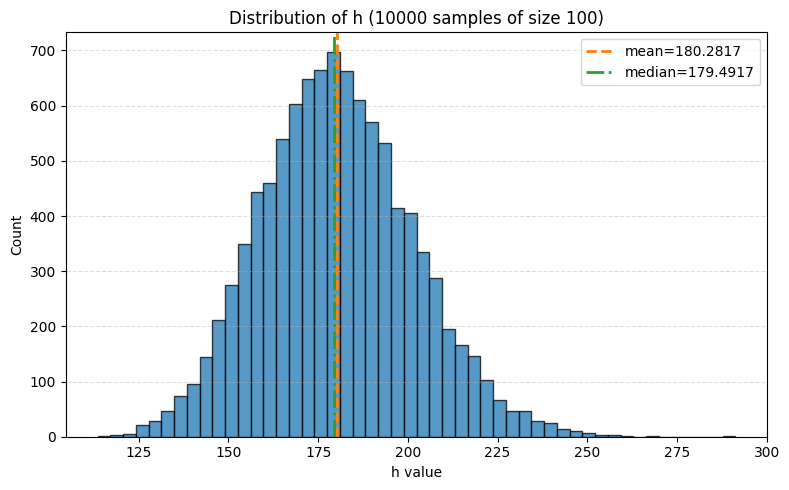

In [ ]:
fig_dir = project_root / 'results' 
fig_dir.mkdir(parents=True, exist_ok=True)

# convert to numpy array and compute basic stats
h_arr = np.array(h)
mean_h = np.mean(h_arr)
median_h = np.median(h_arr)
std_h = np.std(h_arr)

# Plot
plt.figure(figsize=(8,5))
plt.hist(h_arr, bins=50, density=False, alpha=0.75, color='C0', edgecolor='k')
# mean & median lines
plt.axvline(mean_h, color='C1', linestyle='--', linewidth=2, label=f'mean={mean_h:.4f}')
plt.axvline(median_h, color='C2', linestyle='-.', linewidth=2, label=f'median={median_h:.4f}')
plt.xlabel('h value')
plt.ylabel('Count')
plt.title('Distribution of h (10000 samples of size 100)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

# save figure
out_path = fig_dir / 'h_distribution.png'
plt.tight_layout()
plt.savefig(out_path, dpi=150)
print(f'Saved histogram to: {out_path}')
plt.show()